# TruthfulQA: Hallucination Detection via Semantic Entropy & Embedding Geometry

TruthfulQA tests whether models generate truthful answers to questions designed to elicit common misconceptions. Responses were generated by Flan-T5-Base at temperature 1.0 (20 per question) and judged by GPT-4-mini.

Key characteristics:
- 500 questions, 10,000 responses
- High incorrect rate (~70.2%) — questions exploit common misconceptions
- Notable refusal rate (148 responses, 1.5%) — highest among all datasets
- 90 raw domain labels — worst sprawl of all datasets
- Mix of adversarial and non-adversarial questions (all are adversarial by design)
- `type` column is empty (not meaningful)

**Pipeline overview:**
1. Load and inspect the raw response-level data
2. Response-level EDA (label breakdown by domain)
3. Domain analysis (raw domains, canonical consolidation, consistency)
4. Embed all responses with SentenceTransformer
5. Extract 5 geometric features per question
6. Question-level EDA (label profiles, naive vs strict rates)
7. Geometric feature exploration (distributions, correlations, pairplot)
8. Statistical tests (KS tests, permutation test)
9. Classification and ablation
10. Feature importance and SHAP
11. UMAP visualisation (optional)


## Setup

In [ ]:
# Uncomment to install dependencies:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from hallucination_utils import *

print('All imports loaded.')
%load_ext autoreload
%autoreload 2

All imports loaded.


## Configuration

In [2]:
# ── Paths ──
DATA_PATH = './data/truthfulqa_t1.0_n20.jsonl'
OUTPUT_DIR = 'truthfulqa_output'
EMBED_CACHE = 'truthfulqa_embeddings.npy'

# ── Feature extraction ──
SIM_THRESHOLD = 0.85

# ── Statistical tests ──
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

# ── Per-domain ML threshold ──
MIN_QUESTIONS_FOR_ANALYSIS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)


## Load Data

`load_dataset()` handles column normalisation, ensures `prompt_id` exists,
and adds `answer_len`.


In [3]:
df = load_dataset(DATA_PATH)
print_loading_summary(df)


Dataset:          truthfulqa
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2827  (28.3%)
  incorrect   :   7025  (70.2%)
  refused     :    148  (1.5%)

Domains (90 unique)  (showing 10 of 90):
  Agriculture
  Agriculture & Animal Welfare
  Animal Behavior
  Animal Behavior and Learning
  Animal Welfare
  Animal Welfare & Agriculture
  Animals & Wildlife
  Art & History
  Arts
  Arts and Culture
  ...


In [4]:
# Question-level metadata
q_meta = compute_question_metadata(df)
print_domain_consistency(q_meta)


Domain inconsistency: 178/500 questions (35.6%)
Max unique domains per question: 8


In [5]:
# Raw questions per domain (top 15)
raw_domain_counts = questions_per_domain(df)
print(f'Questions per domain (raw) — {len(raw_domain_counts)} domains:')
for dom, n in raw_domain_counts.head(15).items():
    print(f'  {dom:45s}: {n}')
if len(raw_domain_counts) > 15:
    print(f'  ... and {len(raw_domain_counts) - 15} more domains')


Questions per domain (raw) — 90 domains:
  Social Sciences                              : 218
  Humanities                                   : 178
  STEM                                         : 136
  Medicine & Health                            : 61
  Law, Business, and Miscellaneous             : 37
  History                                      : 10
  Science & Nature                             : 7
  Science                                      : 7
  Geography                                    : 5
  Hum Humanities                               : 4
  Biology & Animal Behavior                    : 4
  Linguistics                                  : 4
  Sports                                       : 3
  Natural Sciences                             : 3
  Entertainment                                : 3
  ... and 75 more domains


## Domain Analysis

TruthfulQA has the worst domain sprawl: 90 raw domains with 36% inconsistency. Canonical consolidation is essential. The refusal rate is also the highest across all datasets, making the naive-vs-strict rate comparison particularly informative.


In [6]:
# Apply canonical domain consolidation
df = add_canonical_domain(df)
q_meta_canon = compute_question_metadata(df, domain_col='domain_canonical')

canon_counts = questions_per_domain(df, domain_col='domain_canonical')
print(f'Canonical domains ({len(canon_counts)}):')
for dom, n in canon_counts.items():
    print(f'  {dom:30s}: {n}')

print()
print_domain_consistency(q_meta_canon)


Canonical domains (16):
  Social Sciences               : 218
  Humanities                    : 180
  STEM                          : 136
  Medicine & Health             : 61
  Law & Business                : 45
  Other                         : 18
  Science                       : 18
  History                       : 11
  Entertainment                 : 6
  Geography                     : 6
  Literature                    : 5
  Language                      : 4
  Religion & Philosophy         : 4
  Food & Nutrition              : 3
  Mathematics                   : 3
  Sports                        : 3

Domain inconsistency: 176/500 questions (35.2%)
Max unique domains per question: 5


## Response-Level EDA

Label breakdown at the response level, using both raw and canonical domains.


In [7]:
# Response-level counts
resp_counts = df['correctness'].value_counts()
resp_pcts = (resp_counts / len(df) * 100).round(1)
print('Response-level label distribution:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        print(f'  {lab:12s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')


Response-level label distribution:
  correct     :   2827  (28.3%)
  incorrect   :   7025  (70.2%)
  refused     :    148  (1.5%)


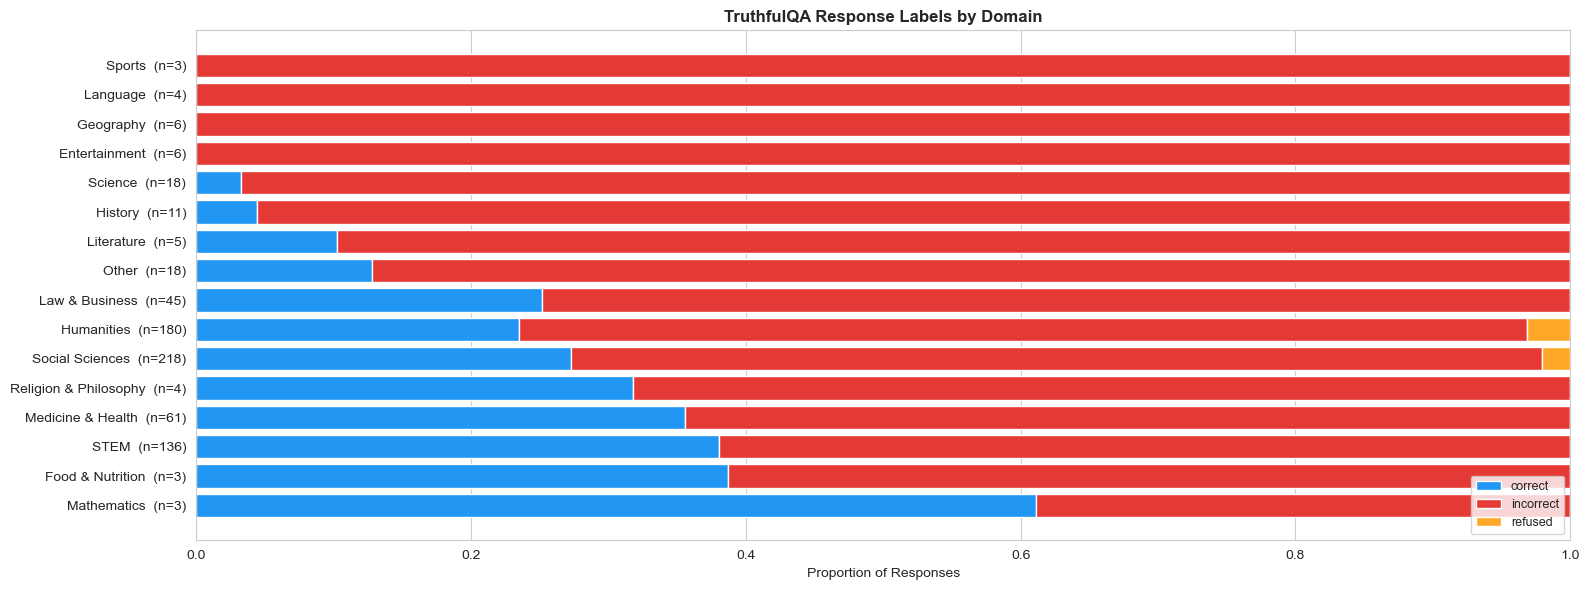

In [8]:
# Stacked bar: canonical domains
fig = plot_response_label_breakdown(
    df,
    domain_col='domain_canonical',
    domain_question_counts=canon_counts,
    title_prefix='TruthfulQA Response Labels',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()


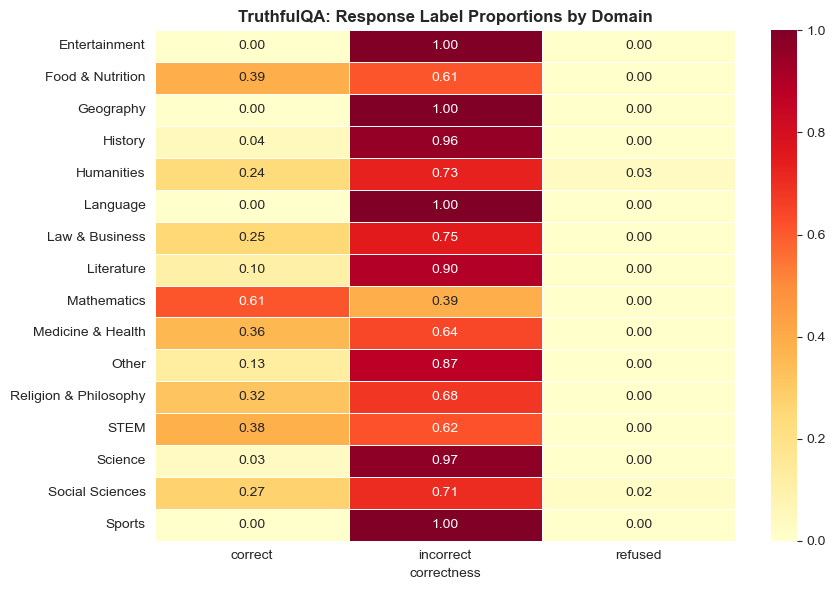

In [9]:
# Heatmap: canonical domains
fig = plot_label_proportion_heatmap(
    df,
    domain_col='domain_canonical',
    title='TruthfulQA: Response Label Proportions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Adversarial vs Non-Adversarial

This dataset contains both adversarial and non-adversarial questions.
We check whether the label distribution differs between them.


In [11]:
ct_adv = pd.crosstab(df['adversarial'], df['correctness'])
ct_adv = ct_adv.reindex(columns=[c for c in LABEL_ORDER if c in ct_adv.columns])
print('Response counts by adversarial flag:')
display(ct_adv)
print()
display(ct_adv.div(ct_adv.sum(axis=1), axis=0).round(3))


Response counts by adversarial flag:


correctness,correct,incorrect,refused
adversarial,,,
False,2820,6777,124
True,7,248,24


correctness,correct,incorrect,refused
adversarial,,,
False,0.290,0.697,0.013
True,0.025,0.889,0.086


## Embed All Responses

We embed every response regardless of correctness label. The geometric
features use all 20 embeddings per question.


In [12]:
all_embeddings = embed_responses(
    df,
    model_name='all-MiniLM-L6-v2',
    cache_path=EMBED_CACHE,
    batch_size=256,
)
print(f'Embedding matrix: {all_embeddings.shape}')


Loading cached embeddings from truthfulqa_embeddings.npy
Embedding matrix: (10000, 384)


## Feature Extraction

Per question: 5 geometric features from all 20 embeddings, label fractions,
strict hallucination rate (excluding refused from denominator), and binary label.


In [13]:
mu_ref, cov_inv = fit_reference_distribution(all_embeddings, df)


Correct responses for reference: 2827
Reference fitted. mu shape: (384,), precision shape: (384, 384)


In [14]:
feat_df, skipped, skipped_details = extract_question_features(
    df, all_embeddings, mu_ref, cov_inv,
    sim_threshold=SIM_THRESHOLD,
    domain_col='domain_canonical',
)

feat_df.to_csv(os.path.join(OUTPUT_DIR, 'truthfulqa_features.csv'), index=False)


  500/500 ...

Questions processed: 500
Questions skipped (all refused): 0
Label distribution:
  Correct (0): 140
  Hallucinated (1): 360
  Rate: 72.0%


### Filtering Diagnostic

In [15]:
canon_raw_counts = questions_per_domain(df, domain_col='domain_canonical')
analysis_domains, excluded_domains = print_filtering_diagnostic(
    feat_df, canon_raw_counts, skipped, MIN_QUESTIONS_FOR_ANALYSIS,
    domain_col='domain_canonical', skipped_details=skipped_details,
)


No questions were skipped.

Surviving questions per domain:
  Social Sciences                         :  169 /  218  (dropped 49)
  Humanities                              :  126 /  180  (dropped 54)
  STEM                                    :  101 /  136  (dropped 35)
  Medicine & Health                       :   50 /   61  (dropped 11)
  Law & Business                          :   35 /   45  (dropped 10)
  History                                 :    5 /   11  (dropped 6)  *** BELOW THRESHOLD
  Science                                 :    3 /   18  (dropped 15)  *** BELOW THRESHOLD
  Other                                   :    2 /   18  (dropped 16)  *** BELOW THRESHOLD
  Food & Nutrition                        :    2 /    3  (dropped 1)  *** BELOW THRESHOLD
  Mathematics                             :    2 /    3  (dropped 1)  *** BELOW THRESHOLD
  Language                                :    1 /    4  (dropped 3)  *** BELOW THRESHOLD
  Entertainment                           :    1

## Question-Level EDA

Per-question label profiles and naive vs strict hallucination rate comparison.


In [16]:
frac_cols = ['frac_correct', 'frac_incorrect', 'frac_refused']
print('Per-question label fraction statistics:')
display(feat_df[frac_cols + ['hall_rate_strict', 'hall_rate_naive']].describe().round(3))


Per-question label fraction statistics:


,frac_correct,frac_incorrect,frac_refused,hall_rate_strict,hall_rate_naive
count,500.000,500.000,500.000,500.000,500.000
mean,0.283,0.702,0.015,0.716,0.717
std,0.354,0.353,0.079,0.354,0.354
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.400,0.000,0.450,0.450
50%,0.100,0.900,0.000,0.900,0.900
75%,0.550,1.000,0.000,1.000,1.000
max,1.000,1.000,0.650,1.000,1.000


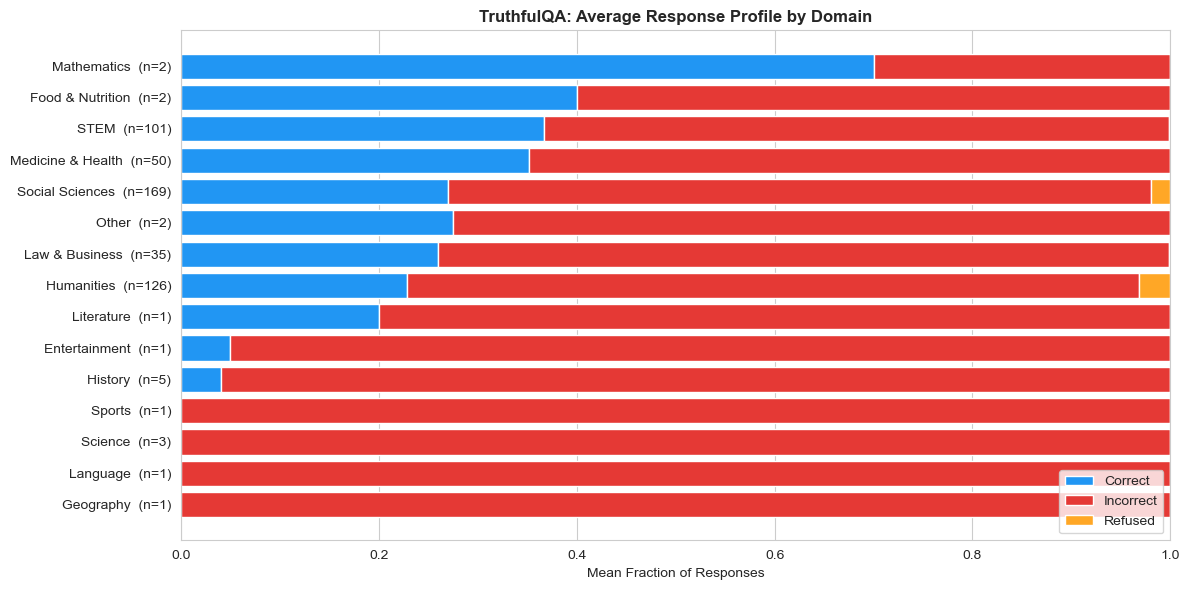

In [17]:
fig = plot_question_label_profiles(
    feat_df,
    frac_cols=['frac_correct', 'frac_incorrect', 'frac_refused'],
    frac_nice_names=['Correct', 'Incorrect', 'Refused'],
    frac_colors=[LABEL_COLORS['correct'], LABEL_COLORS['incorrect'], LABEL_COLORS['refused']],
    domain_col='domain_canonical',
    title='TruthfulQA: Average Response Profile by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_question_label_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()


### Domain Summary Table

In [20]:
domain_stats = build_domain_stats(
    feat_df,
    strict_rate_col='hall_rate_strict',
    domain_col='domain_canonical',
    extra_mean_cols=['frac_refused'],
    analysis_domains=analysis_domains,
)
display(domain_stats.round(3))
domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))


,n_questions,n_hallucinated,hall_rate_mean,hall_rate_std,mean_entropy,mean_frac_refused,pct_hallucinated,in_analysis
domain_canonical,,,,,,,,
Geography,1,1,1.000,NaN,-0.000,0.000,100.0,False
Language,1,1,1.000,NaN,2.966,0.000,100.0,False
Science,3,3,1.000,0.000,3.323,0.000,100.0,False
Sports,1,1,1.000,NaN,3.722,0.000,100.0,False
History,5,5,0.960,0.042,0.994,0.000,100.0,False
Entertainment,1,1,0.950,NaN,3.102,0.000,100.0,False
Literature,1,1,0.800,NaN,2.795,0.000,100.0,False
Humanities,126,98,0.768,0.321,2.621,0.031,77.8,True
Law & Business,35,25,0.740,0.315,3.001,0.001,71.4,True


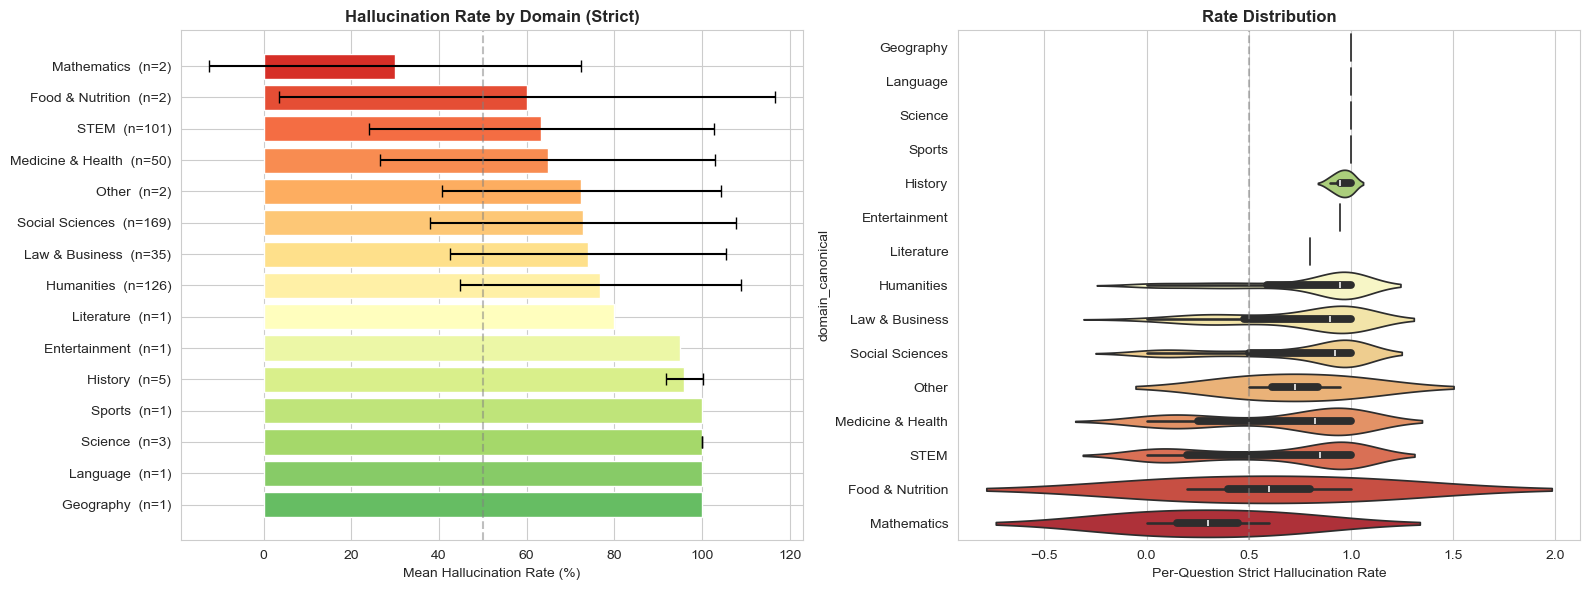

In [21]:
fig = plot_hallucination_rate_by_domain(
    feat_df, domain_stats,
    strict_rate_col='hall_rate_strict',
    domain_col='domain_canonical',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
plt.show()


## Geometric Feature Distributions

The 5 embedding-geometry features, split by the binary target label.


In [22]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    display(sub[GEO_FEATURES].describe().round(4))


--- Correct (n=140) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,140.0000,140.0000,140.0000,140.0000,140.0000
mean,1.7053,0.1592,15.7019,6.6143,0.0547
std,1.2778,0.1279,9.5719,4.9350,0.0404
min,-0.0000,-0.0000,1.7990,1.0000,0.0000
25%,0.5690,0.0471,7.0637,2.0000,0.0182
50%,1.4872,0.1486,14.7829,5.5000,0.0516
75%,2.6870,0.2501,23.9419,10.0000,0.0833
max,4.0219,0.4424,33.6173,17.0000,0.1536


--- Hallucinated (n=360) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,360.0000,360.0000,360.0000,360.0000,360.0000
mean,2.8246,0.2784,37.8444,11.4444,0.0474
std,1.3307,0.1502,10.9522,5.9918,0.0301
min,-0.0000,-0.0000,1.7990,1.0000,0.0000
25%,1.8374,0.1490,34.8094,6.0000,0.0268
50%,3.2848,0.3008,40.6376,12.0000,0.0393
75%,3.9842,0.4059,44.8805,17.0000,0.0629
max,4.3219,0.5781,56.9771,20.0000,0.1585


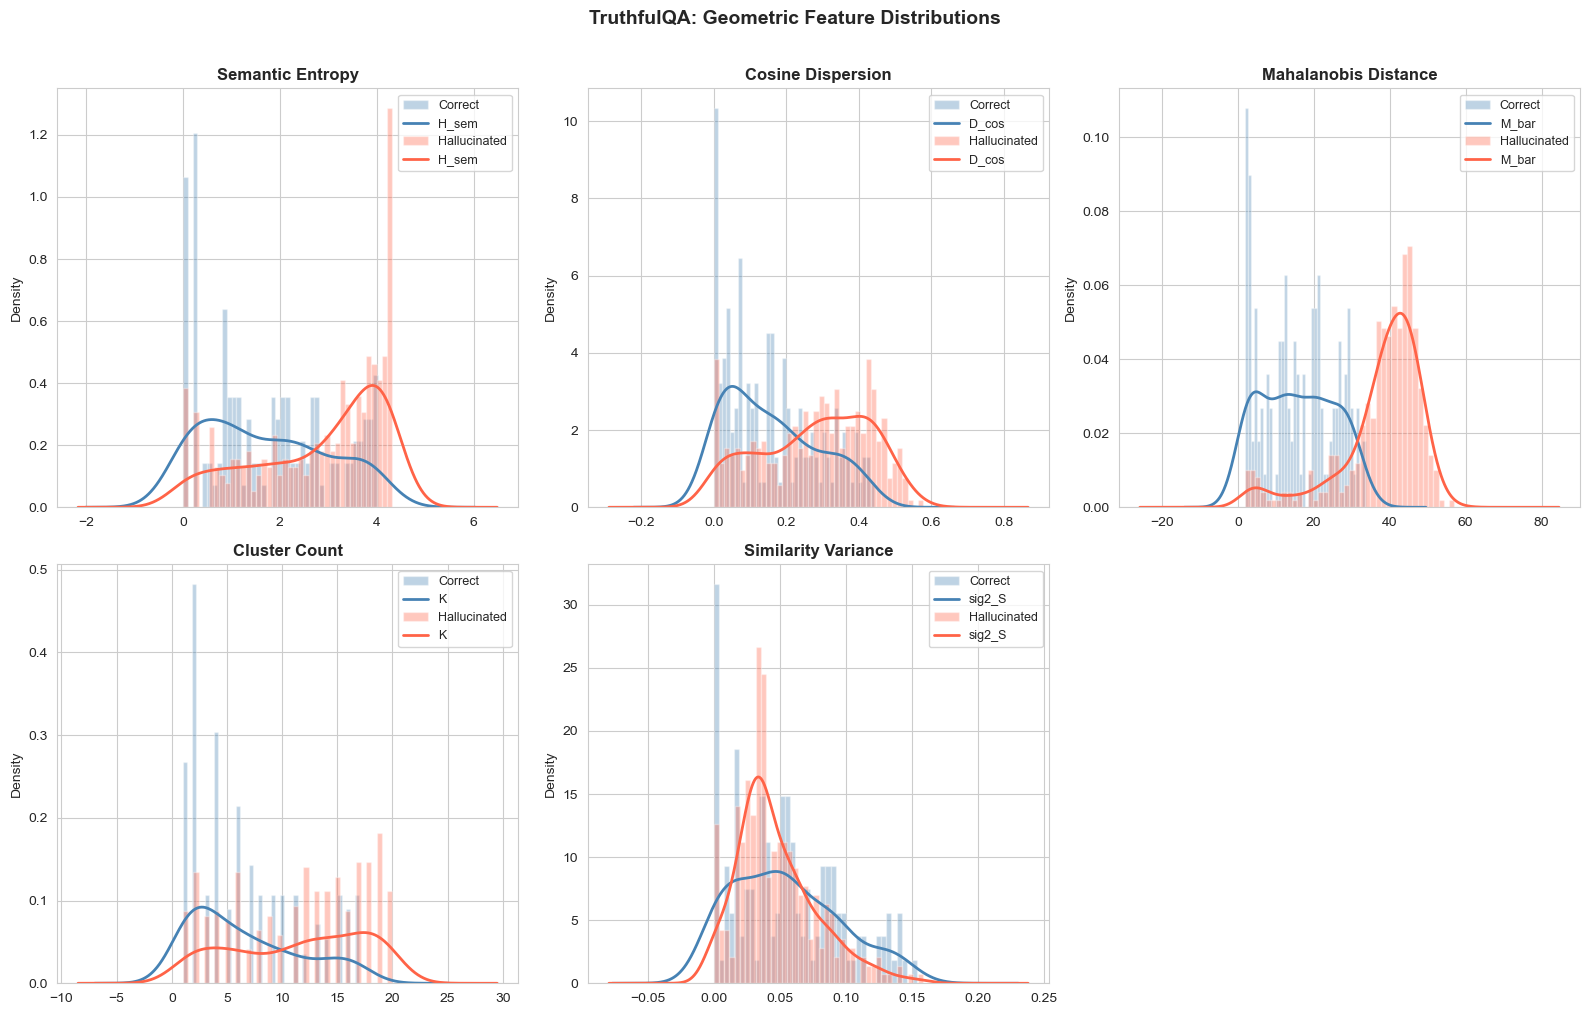

In [23]:
fig = plot_feature_distributions(
    feat_df,
    suptitle='TruthfulQA: Geometric Feature Distributions',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


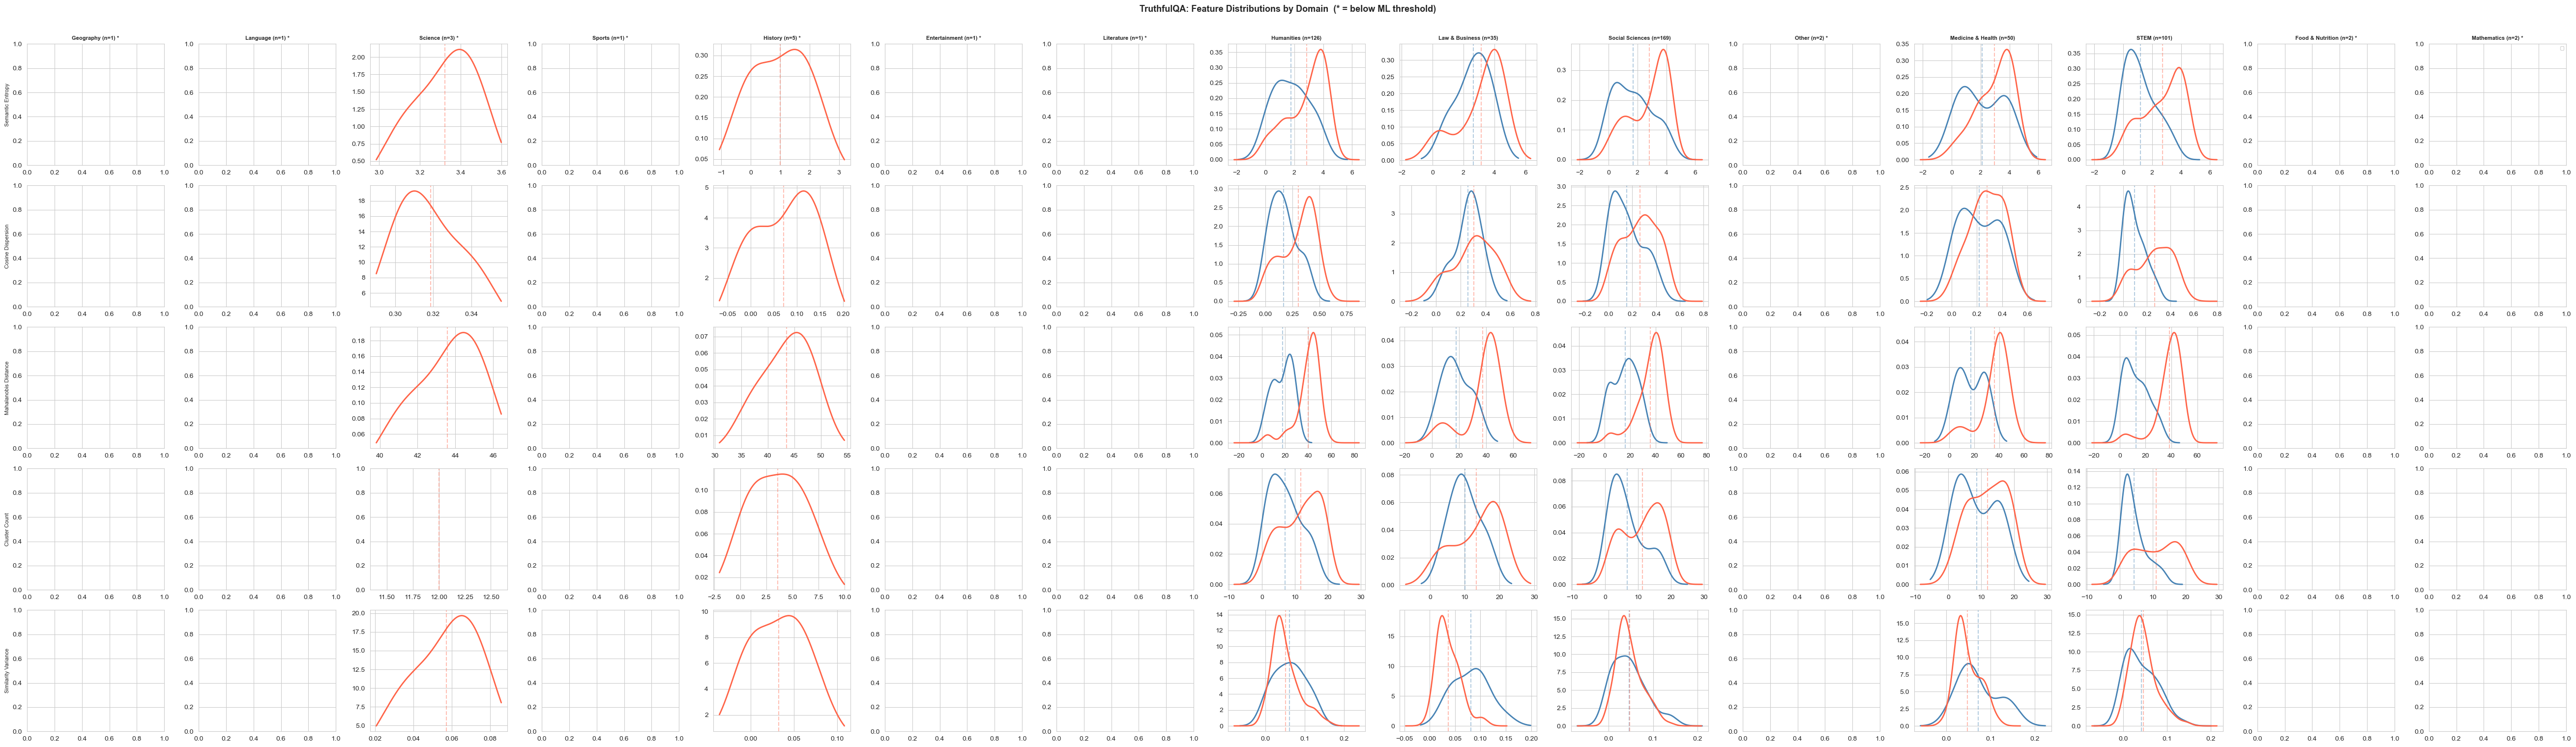

In [24]:
domains_ordered = domain_stats.reset_index()['domain_canonical'].tolist()

fig = plot_per_domain_feature_kdes(
    feat_df,
    domains_ordered=domains_ordered,
    domain_col='domain_canonical',
    analysis_domains=analysis_domains,
    suptitle='TruthfulQA: Feature Distributions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_kde_by_domain.png'), dpi=120, bbox_inches='tight')
plt.show()


### Correlation Analysis

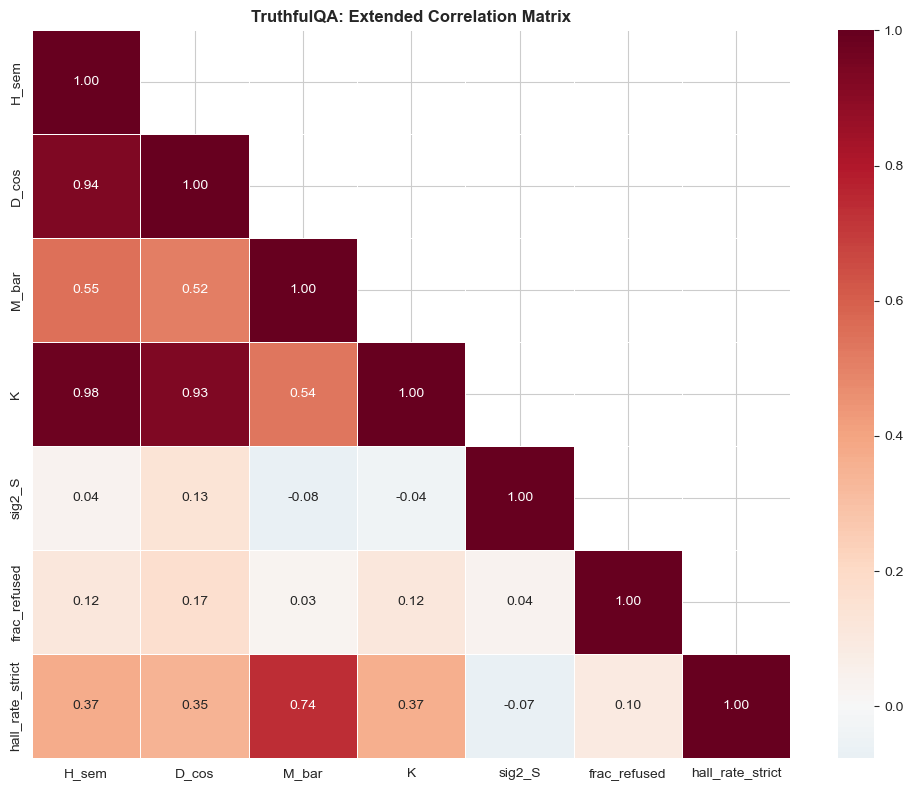

In [25]:
corr_cols = GEO_FEATURES + ['frac_refused', 'hall_rate_strict']
fig = plot_correlation_matrix(
    feat_df, cols=corr_cols,
    title='TruthfulQA: Extended Correlation Matrix',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


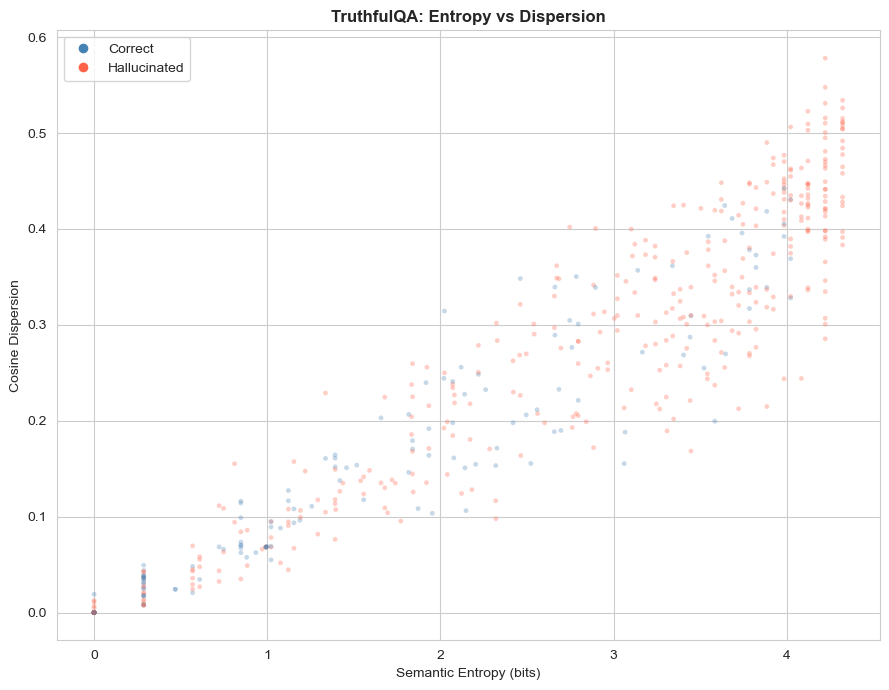

In [26]:
fig = plot_entropy_vs_dispersion(feat_df, title='TruthfulQA: Entropy vs Dispersion')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()


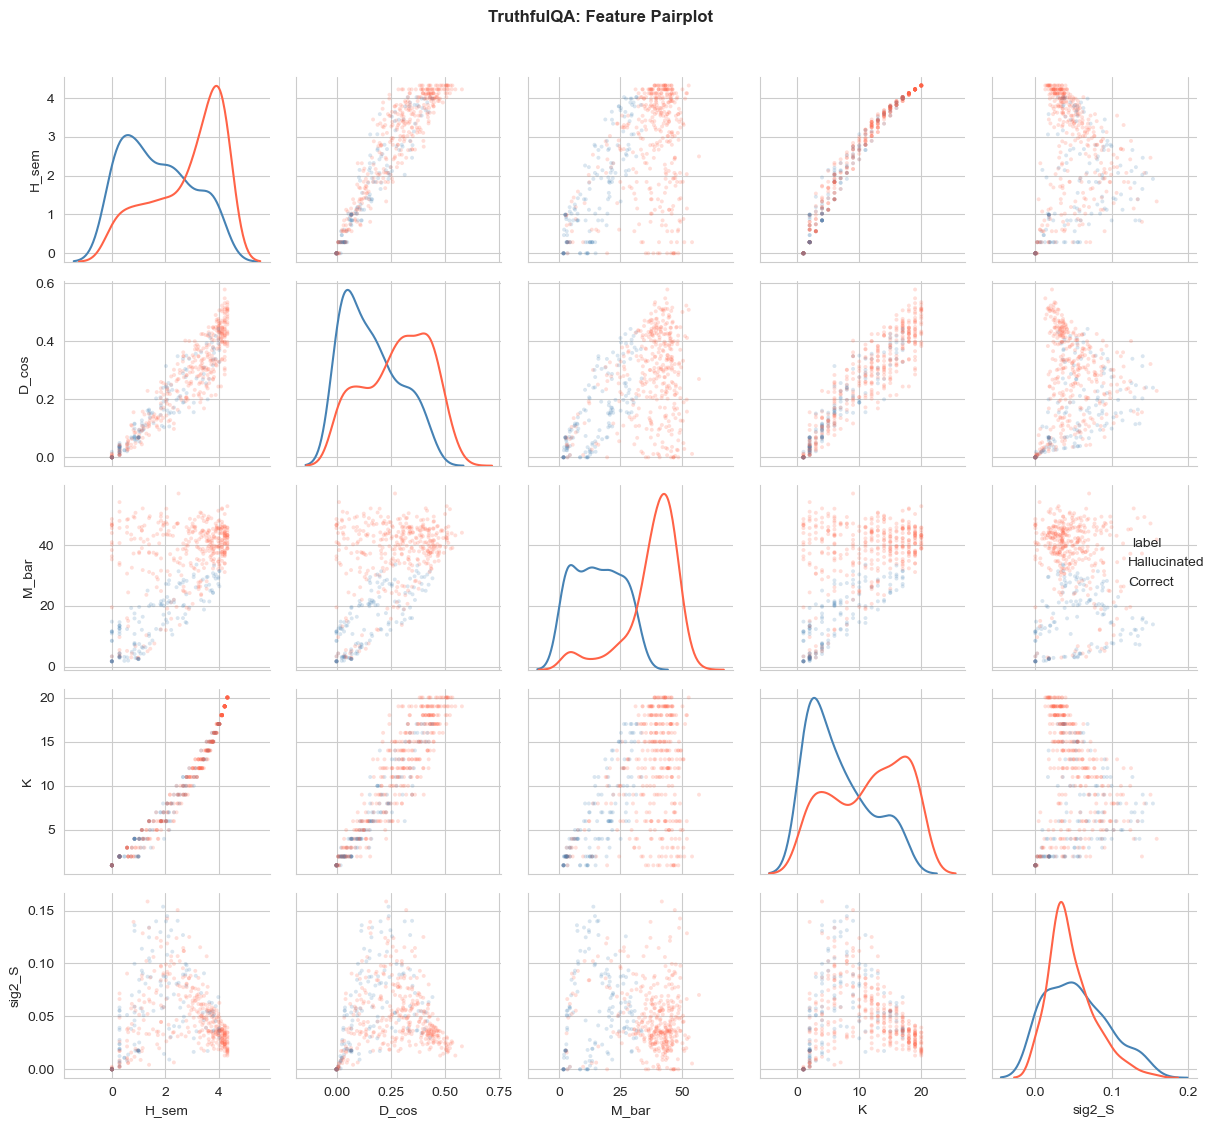

In [27]:
fig = plot_feature_pairplot(feat_df, suptitle='TruthfulQA: Feature Pairplot')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()


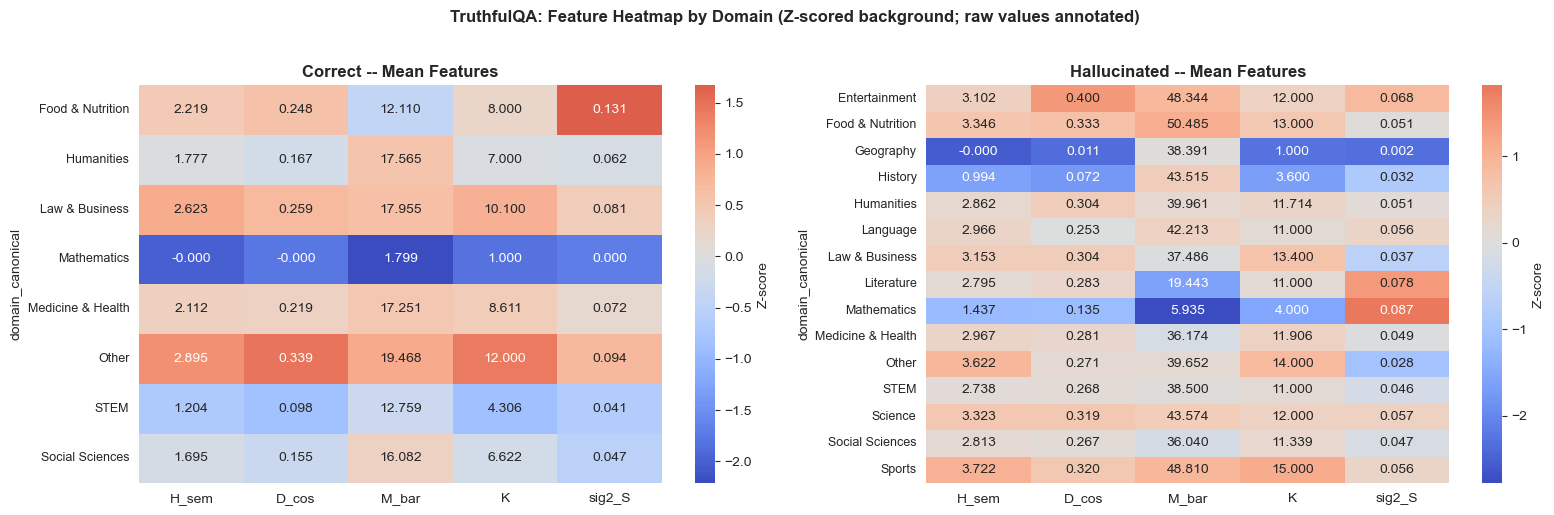

In [28]:
fig = plot_domain_feature_heatmaps(
    feat_df, domain_col='domain_canonical',
    suptitle='TruthfulQA: Feature Heatmap by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()


## Statistical Tests

### KS Tests — Global and Per-Domain


In [29]:
from scipy.stats import ks_2samp

print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)


Global KS tests (Bonferroni alpha = 0.01):
  H_sem       D=0.3929  p=1.98e-14  ***
  D_cos       D=0.3762  p=3.06e-13  ***
  M_bar       D=0.8107  p=6.19e-68  ***
  K           D=0.3687  p=1.01e-12  ***
  sig2_S      D=0.1552  p=1.38e-02  *


In [30]:
all_domains = sorted(feat_df['domain_canonical'].unique())
n_tests = len(GEO_FEATURES) * len(all_domains)
alpha_bonf = 0.05 / n_tests
print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

ks_rows = []
for dom in all_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    for feat in GEO_FEATURES:
        g0 = df_d[df_d['label'] == 0][feat].values
        g1 = df_d[df_d['label'] == 1][feat].values
        if len(g0) < 2 or len(g1) < 2:
            continue
        stat, p = ks_2samp(g0, g1)
        ks_rows.append({
            'Domain': dom, 'Feature': feat,
            'KS_stat': round(stat, 4), 'p_value': p,
            'Significant': p < alpha_bonf,
            'n_questions': len(df_d),
        })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
display(df_ks)


Tests: 75, Bonferroni alpha: 0.000667


,Domain,Feature,KS_stat,p_value,Significant,n_questions
0,Humanities,H_sem,0.4439,2.265470e-04,True,126
1,Humanities,D_cos,0.4643,9.387872e-05,True,126
2,Humanities,M_bar,0.8776,2.013358e-18,True,126
3,Humanities,K,0.3980,1.393146e-03,False,126
4,Humanities,sig2_S,0.2398,1.421992e-01,False,126
5,Law & Business,H_sem,0.4800,5.565908e-02,False,35
6,Law & Business,D_cos,0.2800,5.636770e-01,False,35
7,Law & Business,M_bar,0.8400,1.319320e-05,True,35
8,Law & Business,K,0.4400,9.825521e-02,False,35
9,Law & Business,sig2_S,0.6000,6.911190e-03,False,35


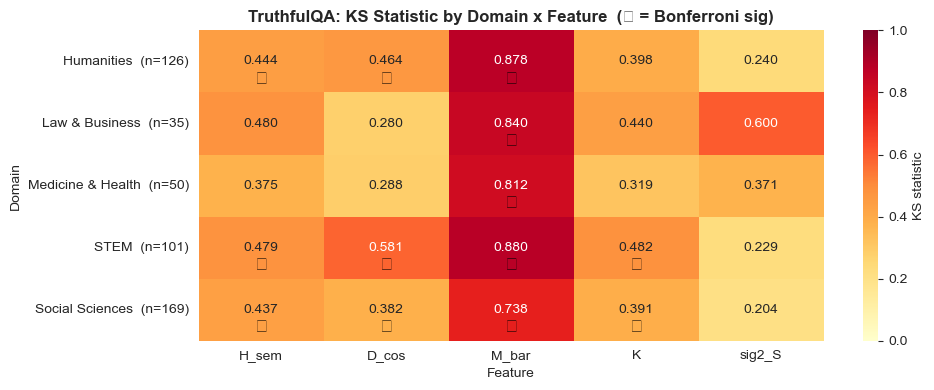

In [31]:
survived_counts = feat_df['domain_canonical'].value_counts()
fig = plot_ks_heatmap(
    df_ks, survived_counts=survived_counts,
    title='TruthfulQA: KS Statistic by Domain x Feature',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ks_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Permutation Test on Entropy Difference

Observed delta (hallu - correct): 1.1194 bits
Permutation p-value (10000 iters): 0.000000


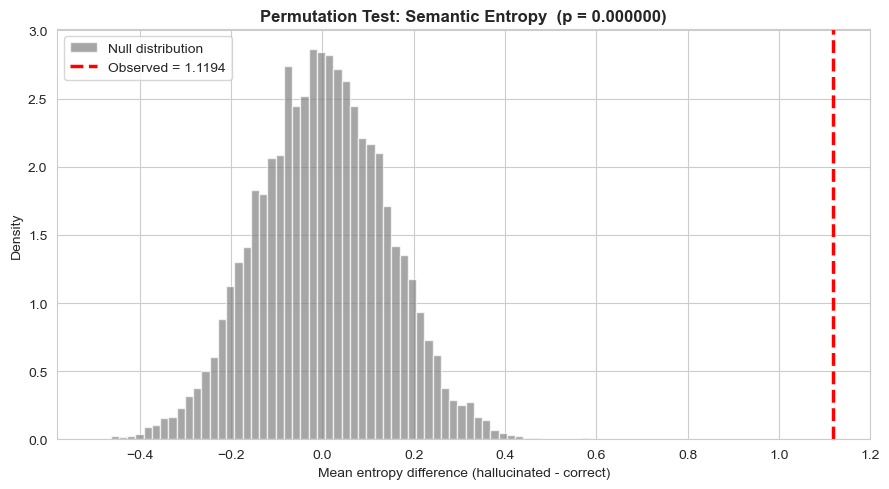

In [32]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu   = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs   = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent    = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig = plot_permutation_test(perm_deltas, delta_obs, N_PERMUTATIONS, perm_pval)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


## Classification and Ablation

Feature subsets × classifiers using 5-fold stratified CV.


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from collections import Counter
import xgboost as xgb

EXTENDED_FEATURES = GEO_FEATURES + ['frac_refused']

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
    ),
}

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused':              ('ext', list(range(len(EXTENDED_FEATURES)))),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.7277 +/- 0.0564
  Entropy only (H_sem)                | Random Forest          | AUC = 0.6403 +/- 0.0780
  Entropy only (H_sem)                | XGBoost                | AUC = 0.6416 +/- 0.0571
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9235 +/- 0.0318
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9297 +/- 0.0334
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.9177 +/- 0.0375
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9231 +/- 0.0322
  Entropy + Geometry                  | Random Forest          | AUC = 0.9319 +/- 0.0366
  Entropy + Geometry                  | XGBoost                | AUC = 0.9232 +/- 0.0376
  All 5 geometric                     | Logistic Regression    | AUC = 0.9220 +/- 0.0338
  All 5 geometric                     | Random Forest          | AUC = 0.9325 +/- 0.0436
  All 5 geometric    

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 + refused,0.928,0.935,0.936
All 5 geometric,0.922,0.932,0.935
Entropy + Geometry,0.923,0.932,0.923
Entropy only (H_sem),0.728,0.640,0.642
"Geometry only (D_cos, M_bar)",0.923,0.930,0.918


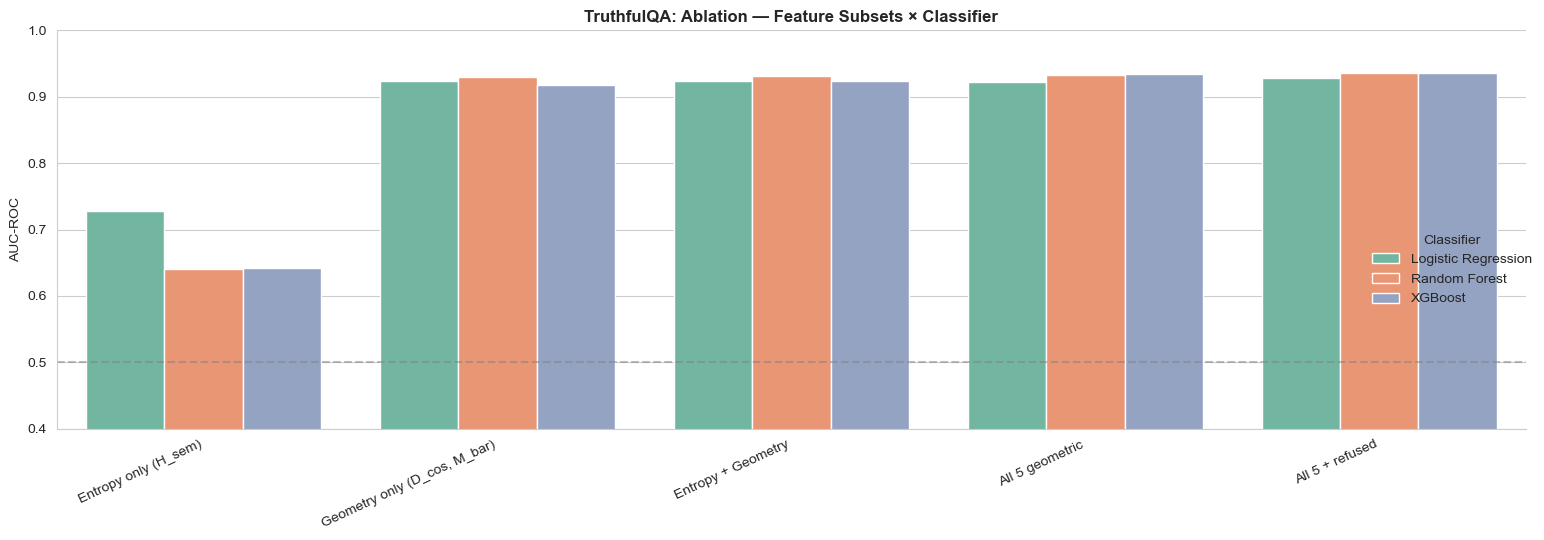

In [34]:
g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('TruthfulQA: Ablation — Feature Subsets × Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


### Per-Domain Classification

In [35]:
domain_clf_rows = []

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = df_d[GEO_FEATURES].values
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'  Skipping {dom} (single class)')
        continue
    X_d_sc = StandardScaler().fit_transform(X_d)
    for clf_name, clf in classifiers.items():
        n_folds = min(5, min(Counter(y_d).values()))
        if n_folds < 2:
            continue
        cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
        domain_clf_rows.append({
            'Domain': dom, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            'n_questions': len(df_d),
        })

if excluded_domains:
    print(f'Excluded (< {MIN_QUESTIONS_FOR_ANALYSIS} questions): {excluded_domains}')

df_dom_clf = pd.DataFrame(domain_clf_rows)
df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))


Excluded (< 10 questions): ['Entertainment', 'Food & Nutrition', 'Geography', 'History', 'Language', 'Literature', 'Mathematics', 'Other', 'Science', 'Sports']


Classifier,Logistic Regression,Random Forest,XGBoost
Domain,,,
Humanities,0.924,0.906,0.922
Law & Business,0.920,0.860,0.900
Medicine & Health,0.835,0.910,0.885
STEM,0.949,0.949,0.941
Social Sciences,0.908,0.893,0.893


### Bootstrap AUC Confidence Intervals

In [36]:
rng_boot = np.random.default_rng(RANDOM_SEED)

print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    if len(np.unique(y_all[idx])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')


Global bootstrap (RF, 5 geometric features):
  AUC = 0.9295  95% CI [0.8950, 0.9601]


In [37]:
boot_rows = []
print('Per-domain bootstrap:')
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        continue
    auc_list = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
        oob = np.setdiff1d(np.arange(len(y_d)), idx)
        if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
            continue
        if len(np.unique(y_d[idx])) < 2:
            continue
        rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
        rf_b.fit(X_d[idx], y_d[idx])
        proba = rf_b.predict_proba(X_d[oob])[:, 1]
        auc_list.append(roc_auc_score(y_d[oob], proba))
    if len(auc_list) < 10:
        continue
    arr = np.array(auc_list)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    boot_rows.append({
        'Domain': dom, 'AUC_mean': arr.mean(),
        'CI_low': lo, 'CI_high': hi, 'n_questions': len(df_d),
    })
    print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]  (n={len(df_d)})')

if excluded_domains:
    print(f'\nExcluded: {excluded_domains}')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True)
df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)


Per-domain bootstrap:
  Humanities                      AUC=0.919  [0.844, 0.978]  (n=126)
  Law & Business                  AUC=0.875  [0.562, 1.000]  (n=35)
  Medicine & Health               AUC=0.900  [0.758, 1.000]  (n=50)
  STEM                            AUC=0.938  [0.856, 0.997]  (n=101)
  Social Sciences                 AUC=0.902  [0.812, 0.965]  (n=169)

Excluded: ['Entertainment', 'Food & Nutrition', 'Geography', 'History', 'Language', 'Literature', 'Mathematics', 'Other', 'Science', 'Sports']


### ROC Curves

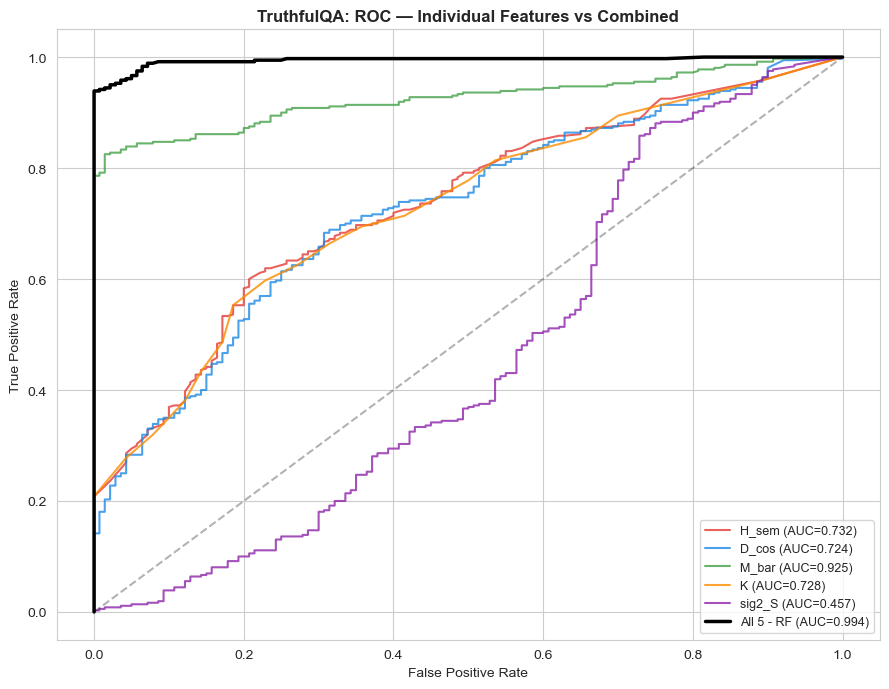

In [38]:
fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('TruthfulQA: ROC — Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


## Feature Importance and SHAP

XGBoost GAIN per domain + SHAP beeswarm plots (analysis domains only).


In [39]:
import shap

xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

importance_data = {}
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        importance_data[dom] = np.zeros(5)
        continue
    xgb_imp.fit(X_d, y_d)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    importance_data[dom] = gains / total if total > 0 else gains

df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
print('Normalized GAIN importance per domain:')
display(df_imp.round(3))


Normalized GAIN importance per domain:


,H_sem,D_cos,M_bar,K,sig2_S
Humanities,0.098,0.150,0.566,0.086,0.100
Law & Business,0.067,0.067,0.666,0.059,0.142
Medicine & Health,0.097,0.102,0.574,0.060,0.167
STEM,0.126,0.113,0.613,0.091,0.057
Social Sciences,0.178,0.107,0.473,0.125,0.117


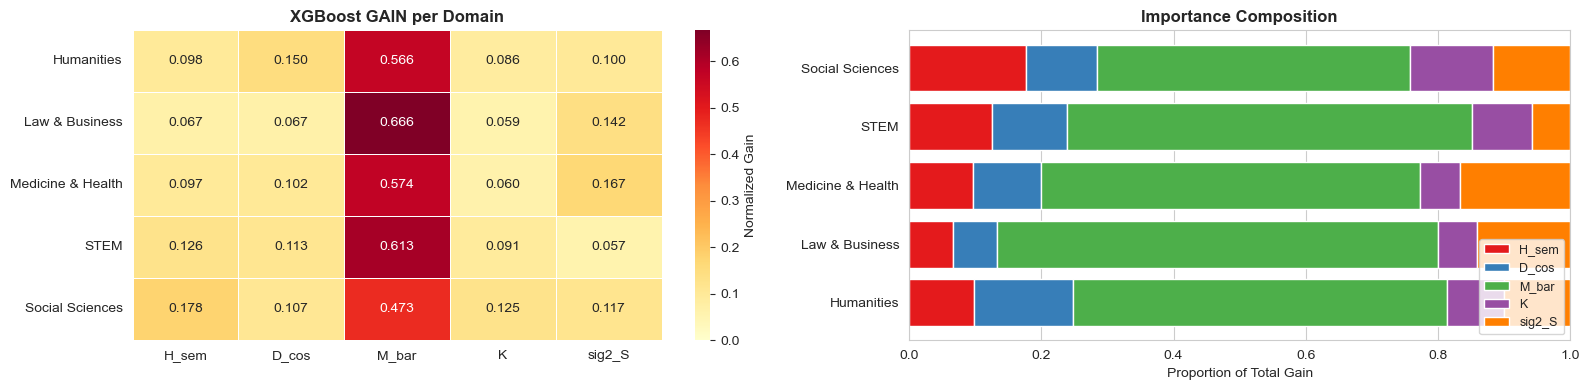

In [40]:
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(analysis_domains) * 0.6 + 1)))

sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=df_imp.values.max(),
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized Gain'})
axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

bottoms = np.zeros(len(df_imp))
for feat, color in zip(GEO_FEATURES, feat_colors_list):
    vals = df_imp[feat].values
    axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
    bottoms += vals
axes[1].set_xlabel('Proportion of Total Gain')
axes[1].set_title('Importance Composition', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


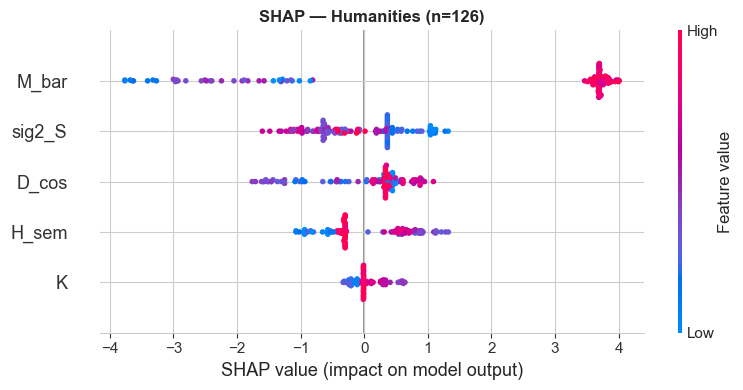

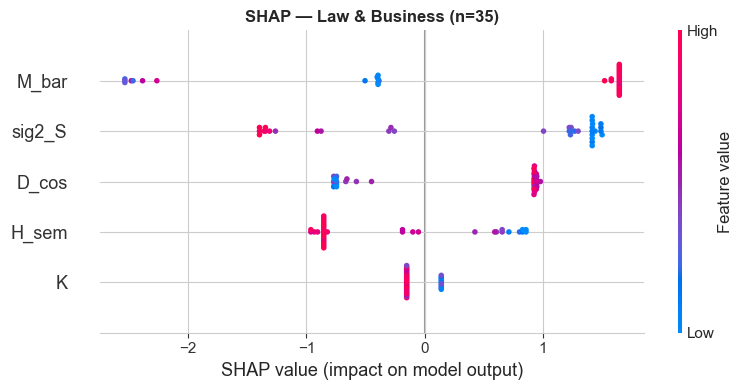

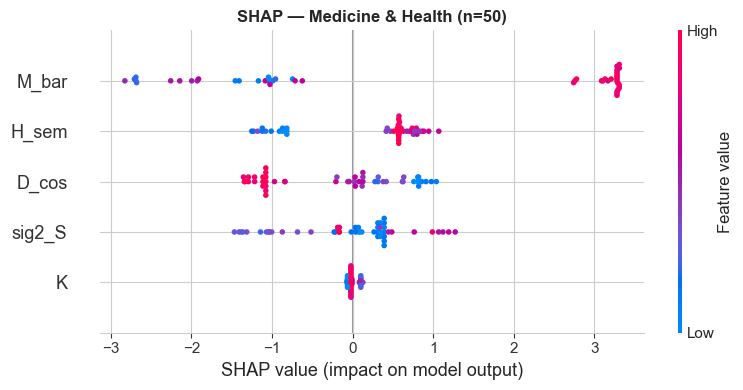

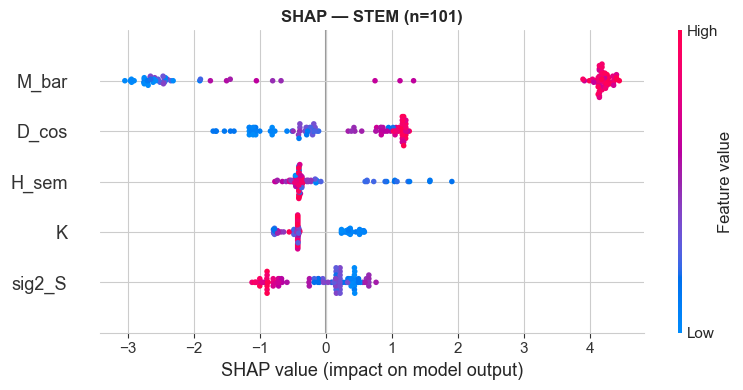

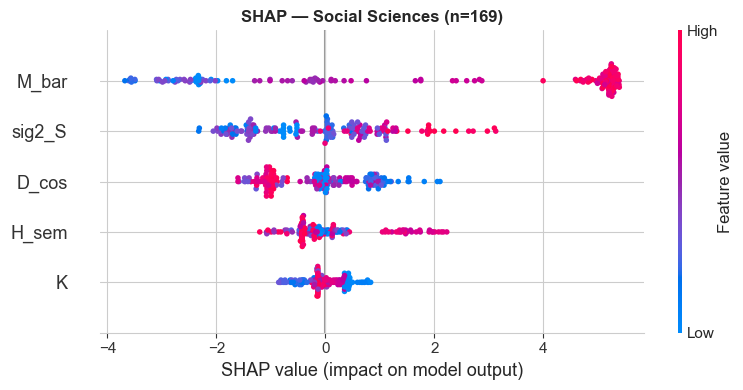

Excluded from per-domain SHAP: ['Entertainment', 'Food & Nutrition', 'Geography', 'History', 'Language', 'Literature', 'Mathematics', 'Other', 'Science', 'Sports']


In [41]:
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain_canonical'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'Skipping {dom}')
        continue
    xgb_shap.fit(X_d, y_d)
    explainer = shap.TreeExplainer(xgb_shap)
    sv = explainer.shap_values(X_d)
    if isinstance(sv, list):
        sv = sv[1]
    plt.figure(figsize=(8, 4))
    shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
    plt.title(f'SHAP — {dom} (n={len(df_d)})', fontweight='bold')
    plt.tight_layout()
    plt.show()

if excluded_domains:
    print(f'Excluded from per-domain SHAP: {excluded_domains}')


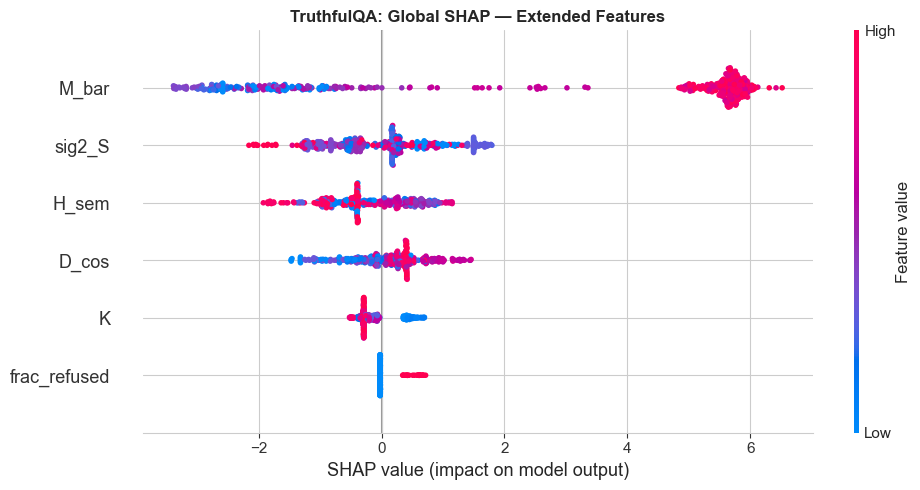

In [42]:
# Global SHAP on extended features
xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('TruthfulQA: Global SHAP — Extended Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_shap_global.png'), dpi=150, bbox_inches='tight')
plt.show()


## UMAP 


Running UMAP on 8000 points...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


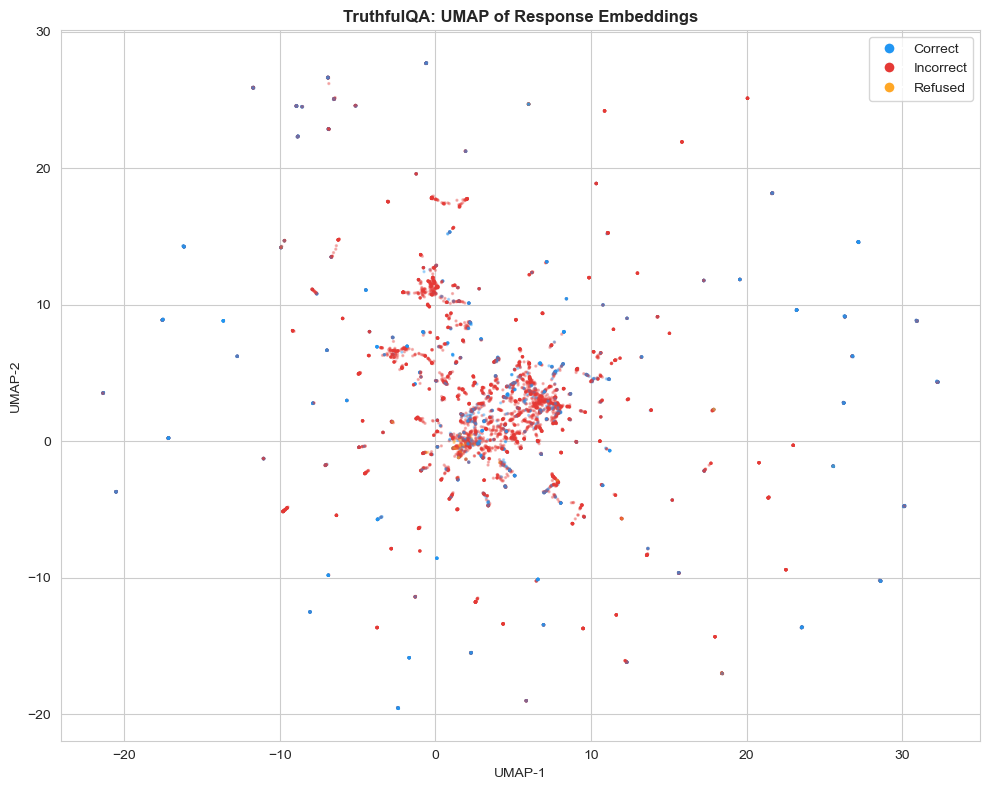

In [43]:
try:
    import umap

    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    fig = plot_umap(proj, lab_sub, title='TruthfulQA: UMAP of Response Embeddings')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()

except ImportError:
    print('umap-learn not installed, skipping UMAP.')


## Summary

In [44]:
print('=' * 70)
print('TRUTHFULQA HALLUCINATION DETECTION — RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: TruthfulQA')
print(f'  Total questions (raw): {df["prompt_id"].nunique()}')
print(f'  Questions analyzed: {len(feat_df)}')
print(f'  Questions skipped (all refused): {skipped}')
print(f'  Samples per question: 20')
print(f'  Canonical domains: {len(all_domains)}')
print(f'  Domains in ML (>= {MIN_QUESTIONS_FOR_ANALYSIS}): {len(analysis_domains)}')
if excluded_domains:
    print(f'  Excluded from ML: {excluded_domains}')
print()

resp_counts = df['correctness'].value_counts()
print('  Response-level breakdown:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        pct = resp_counts[lab] / len(df) * 100
        print(f'    {lab:12s}: {resp_counts[lab]:6d}  ({pct:.1f}%)')
print()

print(f'  Binary label (strict):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()

print(f'  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()

print(f'  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier config:')
print(f'    {best["Classifier"]} / {best["Variant"]} — AUC={best["AUC_mean"]:.4f}')
print()

print(f'  Top feature by domain (XGBoost GAIN):')
for dom, row in df_imp.iterrows():
    top = row.idxmax()
    print(f'    {dom:30s}: {top} ({row[top]:.3f})')
print()
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)


TRUTHFULQA HALLUCINATION DETECTION — RESULTS SUMMARY
  Dataset: TruthfulQA
  Total questions (raw): 500
  Questions analyzed: 500
  Questions skipped (all refused): 0
  Samples per question: 20
  Canonical domains: 15
  Domains in ML (>= 10): 5
  Excluded from ML: ['Entertainment', 'Food & Nutrition', 'Geography', 'History', 'Language', 'Literature', 'Mathematics', 'Other', 'Science', 'Sports']

  Response-level breakdown:
    correct     :   2827  (28.3%)
    incorrect   :   7025  (70.2%)
    refused     :    148  (1.5%)

  Binary label (strict):
    Correct: 140, Hallucinated: 360
    Rate: 72.0%

  Permutation test (entropy):
    delta = 1.1194 bits, p = 0.000000

  Bootstrap AUC (RF, 5 geometric features):
    AUC = 0.9295, 95% CI [0.8950, 0.9601]

  Best classifier config:
    XGBoost / All 5 + refused — AUC=0.9360

  Top feature by domain (XGBoost GAIN):
    Humanities                    : M_bar (0.566)
    Law & Business                : M_bar (0.666)
    Medicine & Health      